# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [45]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [47]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [48]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [49]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [50]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [51]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [52]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [53]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [54]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos
print(users.isna().mean())# Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [55]:
print(usage.isna().sum())
print(usage.isna().mean())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?
- 
En la tabla "users"


-Se observa que se tienen 469 valores nulos en la columna "city" que equivale al 11% de los datos
-También se detectan 3534 valores nulos en la columna "churn_date" que equivale al 88% de los datos.


En el primer caso se podrían imputar los nulos dado que la información de "city" para no generar un impacto en el análisis estadistico.
En el caso de "churn_date" se ignorará la columna dado que contiene más del 80% de valores nulos.



En la tabla "usage"
-Se encontraron 50 datos nulos en la columna "date" lo que equivale al 1% de los datos.
-También se encontraron 22076 datos nulos en la columna "duration" que equivale al 55% de los datos.
-Y se detectan 17896 valores nulos en la columna "length" que equivale al 44% de los datos.

En el caso de la columna "date" se recomienda invalidar los nulos sin eliminar o imputar para realizar análisis estadisticos. Para el caso de "duration" y "lenght", se recomienda ignorar ambas columnas dado que el porccentaje de valores nulos es alto y sesgaria los calculos estadisticos.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [56]:
print(users.describe())# explorar columnas numéricas de users

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` no presenta mucha dispersión en los datos, se observan valores simetricos; se tiene una media y una mediana del mismo valor. Estos datos no generan un alto valor estadisitico al análisis.
- La columna `age` por su parte, aunque no presenta mucha dispersión en los datos, presenta valores invalidos o sentinels dado que no hay edades que puedan ser de -999. Hay que cambiar o invalidar esos datos para que no afecten en los valores estadisticos.

In [57]:
print(usage.describe())# explorar columnas numéricas de usage

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` presentan un alta dispersión en los valores, aunque también se presenta simetria entre los valores dado que la media y la mediana son de valores muy similares. Estos datos no generan un alto valor estadisitico al análisis.
- Las columnas ´duration' y 'length' por su parte, también presentan alta dispersión. Aqui se observa un sesgo a la derecha y el hallazgo de outliers dado que hay mucha diferencia entre el Q3 y el máximo valor.

In [58]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` presenta valores ausentes dado que se cuenta con 4000 registros en las otras columnas y esta presenta 3531 valores. Bogotá es la ciudad más popular, de las 7 ciudades registradas.
- La columna `plan` solo presenta dos valores, siendo "Basico" el más popular.

In [59]:
# explorar columna categórica de usage
usage['type'].describe()# completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene unicamente dos registros, de los cuales, "text" es el más frecuente con 22092 registros.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Urgente corregir valores sentinels en columna 'age' por mediana en tabla users. En las columnas ´duration´y ´length´se presentan outliers. En la columna ´city´ aunque hay valores ausentes lo recomendable seria invalidarlos con NA para que los demás datos se conserven.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [60]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = "coerce")# completa el código

In [61]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors = "coerce")# completa el código

In [62]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`,se encontraron 40 registros de fechas imposibles.

In [63]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts())

2024.0    39950
Name: date, dtype: int64


En `date`, no se detectan fechas anomalas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Se detecta que en la tabla "users" existen 40 valores con discrepancia. Lo ideal seria anular unicamente estos datos para que no se pierda la información que esta vinculada a ellos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [64]:
# Reemplazar -999 por la mediana de age
#print((users['age']== -999).sum())
users['age'] = users['age'].replace(-999, pd.NA)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [65]:

# Reemplazar ? por NA en city
users['city'] = users['city'].fillna("?")

# Verificar cambios
users['city'].describe()


count       4000
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [66]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [67]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [68]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los datos son MAR debido a que la ausencia es por el tipo de información que se maneja, es decir: Para "duration" hay 0% nulos en el grupo de llamada, porque existe la totalidad de la información, en cambio, para texto practicamente el 100% son nulos dado que los textos no se miden por duración. Por otro lado, para "length" el 100% de los datos de llamada son nulos dado que length mide la longitud de los caracteres y para el tipo de dato text existieron 0% nulos por hablarse de esto mismo.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [69]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [70]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [71]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg,users, on = ["user_id"], how = "inner")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [72]:
# Resumen estadístico de las columnas numéricas
user_profile_resumen = user_profile[["cant_mensajes","cant_llamadas","cant_minutos_llamada"]].agg(["mean","median","min","max","std"])
user_profile_resumen

,cant_mensajes,cant_llamadas,cant_minutos_llamada
mean,5.524381,4.478120,23.317054
median,5.000000,4.000000,19.780000
min,0.000000,0.000000,0.000000
max,17.000000,15.000000,155.690000
std,2.358416,2.144238,18.168095


In [73]:
# Distribución porcentual del tipo de plan

distribucion_plan = user_profile["plan"].value_counts(normalize = True) * 100
distribucion_plan


Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

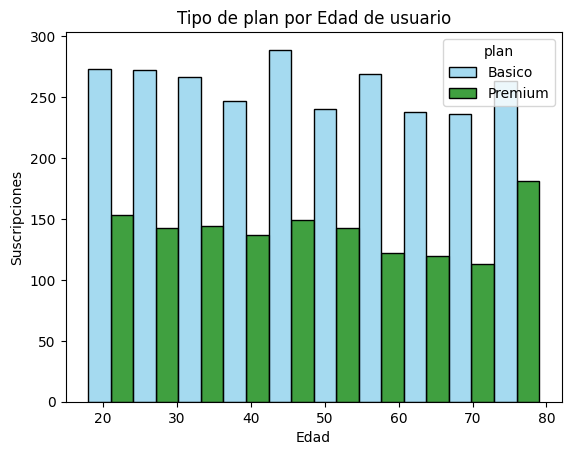

In [74]:
# Histograma para visualizar la edad (age)
sns.histplot(data = user_profile, x = "age", bins = 10, hue = "plan", palette = ["skyblue","green"], multiple = "dodge")
plt.title("Tipo de plan por Edad de usuario")
plt.xlabel("Edad")
plt.ylabel("Suscripciones")

plt.show()

💡Insights: 
- Distribución uniforme para el plan "Premium" oscilando al rededor de 150 suscripciones en todos los rangos de edad, exceptuando a los usuarios entre 70 y 80 años (se eleva un poco más, como al rededor de 190 suscripciones).
- También existe una distribución uniforme en el plan "Basico". Se encuentra que la mayoria de usuarios con este plan se encuentran dentro de un rango de edad entre los 40 y 50 años.
- Se concluye que la mayoria de las suscripciones "Premium" son de usuarios con un rango de edad entre 70 y 80 años.

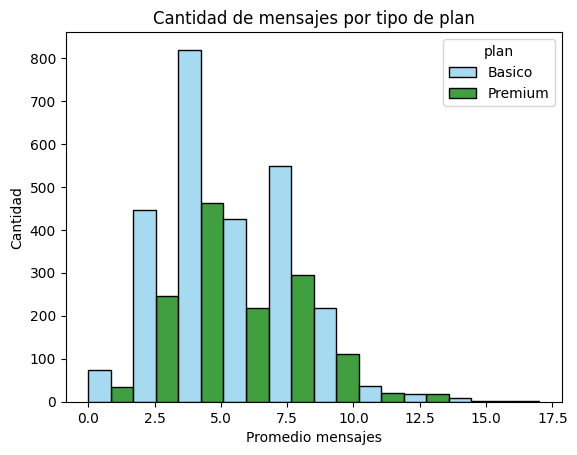

In [75]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile, x="cant_mensajes", bins = 10, hue = "plan", palette= ["skyblue","green"], multiple = "dodge")
plt.title("Cantidad de mensajes por tipo de plan")
plt.xlabel("Promedio mensajes")
plt.ylabel("Cantidad")
plt.show()


💡Insights: 
- Se presenta una distribución con sesgo hacia la derecha para ambos tipos de plan en el promedio de mensajes, lo que indica que la mayoria de usuarios usan pocos mensajes en su plan y unos pocos usuarios usan mucho la mensajeria (más de 10 mensajes en promedio al dia)

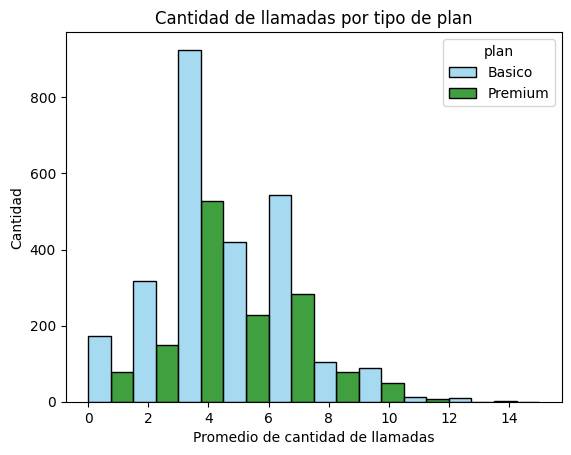

In [76]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas",bins = 10, hue= "plan", palette = ["skyblue", "green"], multiple = "dodge")
plt.title("Cantidad de llamadas por tipo de plan")
plt.xlabel("Promedio de cantidad de llamadas")
plt.ylabel("Cantidad")
plt.show()



💡Insights: 
- Se presenta una distribución con sesgo hacia la derecha para ambos tipos de plan en el promedio de llamadas, lo que indica que la mayoria de usuarios realizan de 4 a 7 llamadas en promedio al dia  y unos pocos usuarios realizan más de 7 llamadas.

Text(0, 0.5, 'Cantidad')

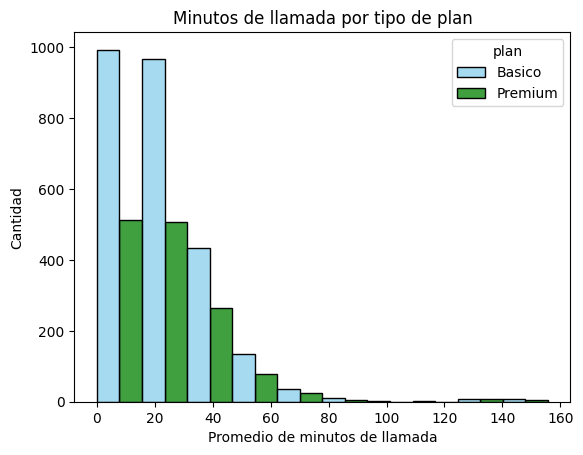

In [77]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x= "cant_minutos_llamada", bins = 10, hue= "plan", palette = ["skyblue", "green"], multiple = "dodge")
plt.title("Minutos de llamada por tipo de plan")
plt.xlabel("Promedio de minutos de llamada")
plt.ylabel("Cantidad")

💡Insights: 
- Se presenta una distribución con sesgo hacia la derecha para ambos tipos de plan en el promedio del total de minutos en las llamadas, lo que indica que la mayoria de usuarios realizan llamadas de 0 a 40 minutos en promedio y unos pocos usuarios realizan llamadas de más de 40 minutos. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

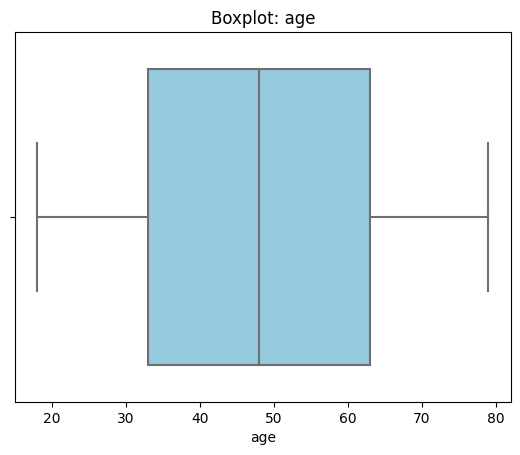

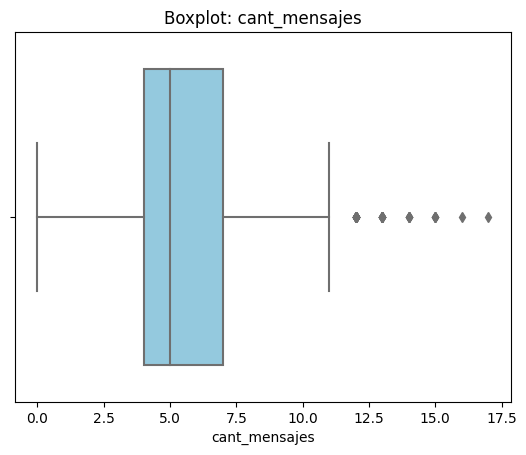

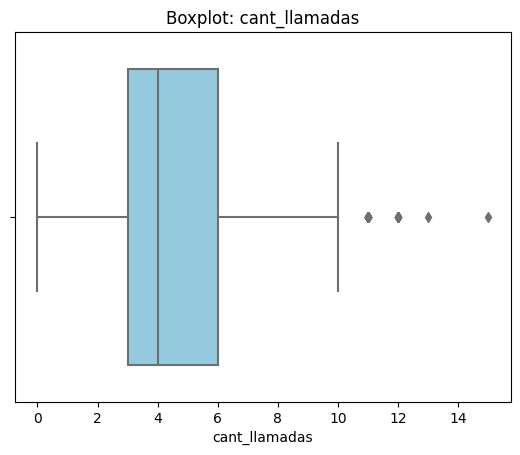

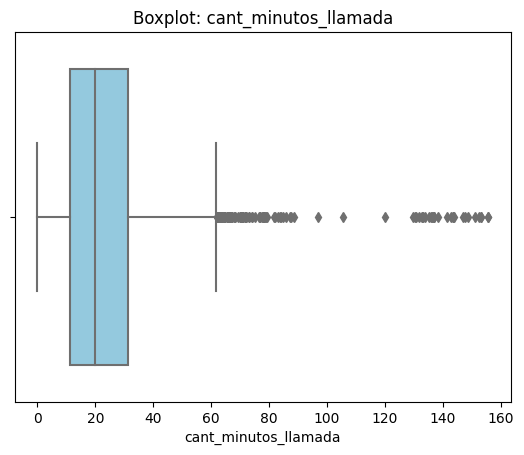

In [78]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(data=user_profile,x=col, color="skyblue")
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age: no presenta outliers, presenta una distribución simetrica.
- cant_mensajes: presenta pocos outliers que no estan muy alejados del limite superior.
- cant_llamadas: presenta pocos outliers que no estan muy alejados del limite superior.
- cant_minutos_llamada: presenta muchos outliers muy alejados del limite superior.

In [79]:
# Calcular límites con el método IQR


IQR = user_profile[columnas_numericas].quantile(0.75) -  user_profile[columnas_numericas].quantile(0.25)
columnas_limites= user_profile[columnas_numericas].quantile(0.75) + 1.5 * IQR 
#limite_inferior= user_profile[columnas_numericas].quantile(0.25) - 1.5 * IQR




In [80]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print("--- Máximos de tus columnas actuales ---")
print(user_profile[columnas_numericas].describe().loc['max'])

print("\n--- Límites Superiores calculados (columnas_limites) ---")
print(columnas_limites)

--- Máximos de tus columnas actuales ---
age                      79.00
cant_mensajes            17.00
cant_llamadas            15.00
cant_minutos_llamada    155.69
Name: max, dtype: float64

--- Límites Superiores calculados (columnas_limites) ---
age                     108.0000
cant_mensajes            11.5000
cant_llamadas            10.5000
cant_minutos_llamada     61.8575
dtype: float64


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Si mantendría los outliers dado que no son muchos y no se encuentran muy alejados del limite superior.
- cant_llamadas: mantener o no outliers, porqué? Si mantendría los outliers dado que no son muchos y no se encuentran muy alejados del limite superior.
- cant_minutos_llamada: mantener o no outliers, porqué? No mantendría los outliers dado que son muchos y estan muy alejados del limite superior, lo que distorisiona el calculo de metricas estadisticas.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [81]:
# Crear columna grupo_uso

def evaluacion (plan):
    if (plan["cant_llamadas"]<5) & (plan["cant_mensajes"]<5):
        return "Bajo uso"
    elif (plan["cant_llamadas"]<10) & (plan["cant_mensajes"]<10):
        return "Uso medio"
    else:
        return "Alto uso"
user_profile["grupo_uso"]= user_profile.apply(evaluacion, axis =1) 

In [82]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [84]:
# Crear columna grupo_edad
def evaluacion_edad (edad):
    if edad["age"]<30:
        return "Joven"
    elif edad["age"]<60:
        return "Adulto"
    else:
        return "Adulto Mayor"
user_profile["grupo_edad"]= user_profile.apply(evaluacion_edad, axis=1)

In [85]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

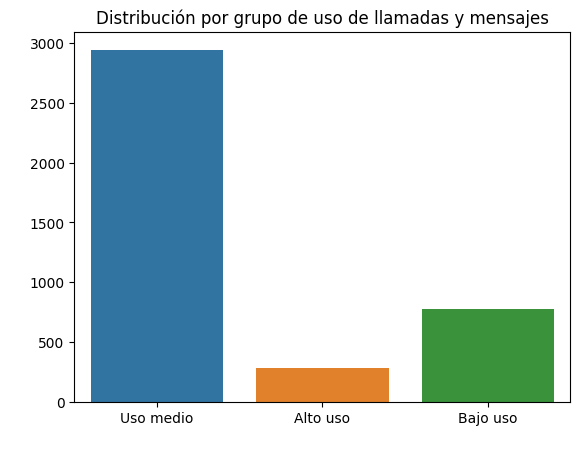

In [92]:
# Visualización de los segmentos por uso
sns.countplot(data= user_profile, x= "grupo_uso")
plt.title("Distribución por grupo de uso de llamadas y mensajes")
plt.xlabel(" ")
plt.ylabel(" ")

plt.show()

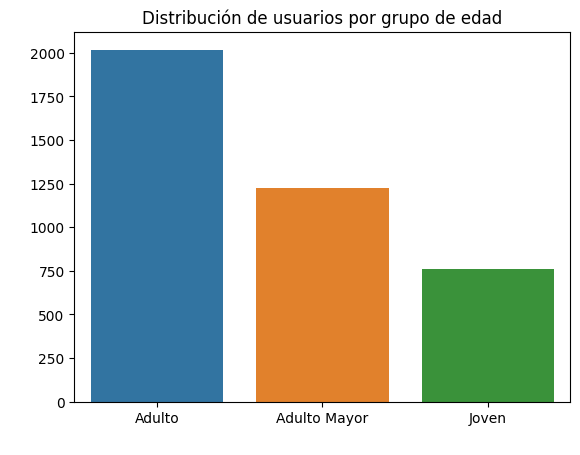

In [94]:
# Visualización de los segmentos por edad
sns.countplot(data = user_profile, x="grupo_edad")
plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron 469 valores nulos en la columna "city" y 3534 valores nulos en la columna "churn_date" de la tabla "users" que equivale al 11% y al 88% de los datos. En el primer caso se rellenaron valores con NA para no afectar a los calculos estadisticos, en el segundo caso se ignoró la columna dado que la mayoria de los datos eran nulos.
- Se encontraron 50 datos nulos en la columna "date" lo que equivale al 1% de los datos. También se encontraron 22076 datos nulos en la columna "duration" que equivale al 55% de los datos y 17896 valores nulos en la columna "length" que equivale al 44% de los datos en la tabla "usage". En el caso de la columna "date" se invalidaron los nulos sin eliminar o imputar, para el caso de "duration" y "lenght", se ignoraron ambas columnas dado que el porccentaje de valores nulos es alto.
- Se encontraron valores de "-999" en la columna age de la tabla users,  valores que se tuvieron que anular.
- Los datos de fecha no tenian formato date y se detectaron fechas fuera del rango de la base de datos (año 2026).

🔍 **Segmentos por Edad**
- Se clasificaron a los usuarios en grupos dependiendo de su edad. Se encontró que la mayoria de los clientes son adultos entre 30 y 60 años, mientras que los usuarios que menos usan el servicio son los jovenes menores de 30 años.
  
📊 **Segmentos por Nivel de Uso**
- Asi mismo, se clasificaron a los clientes por nivel de uso de llamadas y mensajes. Se encontró que la mayoria de los usuarios tiene un uso medio de estos servicios (menor a 10) y muy pocos tienen registrado más de 10 llamadas y mensajes en promedio.


➡️ Esto sugiere que para ConnectaTel cuenta con muchos clientes entre 30 y 60 años, de los cuales, realizan en promedio de 4 a 7 llamadas y mensajes al dia. Se detecta un nicho de alto valor con un rango de edad entre 70 y 80 años ya que son la mayoria con suscripciones "Premium".


Asi mismo, se encontraron algunos valores outliers para la cantidad de llamadas y mensajes que realizan los usuarios que no se alejan tanto del limite superior en promedio. Sin embargo, en el caso de la duración promedio de las llamadas, se detectan bastantes outliers extremos. Lo anterior sugiere la presencia de un grupo reducido de usuarios con un consumo de minutos inusualmente alto. 

💡 **Recomendaciones**
- Dado el consumo de minutos inusualmente alto, existe una oportunidad de ingresos adicionales (por cobro de minutos excedentes en planes básicos) o un indicador para monitorear posibles usos comerciales no autorizados o fraudes en las líneas residenciales.
- Se sugiere crear promociones o planes atractivos para que el nicho de alto valor "premium" aumente en los usuarios de entre 30 y 60 años (podría ser alguna promoción de streaming, datos, et)

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`